
# Exercise #1 - Thompson Sampling and MAB
**Student:** Ali Cihan Ozdemir (9091405)
**Course:** CSCN8020

### Introduction
- **Objective:** Navigate the exploration-exploitation trade-off using various MAB strategies.
- **Round 1 (Stationary):** Addressed using a decaying $\epsilon$-greedy schedule to lock into the optimal arm.
- **Round 2 (Non-Stationary):** Addressed using a constant step-size ($\alpha$) to track moving targets.
- **Thompson Sampling:** Implemented to elegantly balance exploration and exploitation using Bayesian probability.


True means: [0.774 0.439 0.859 0.697 0.094 0.976 0.761 0.786 0.128 0.45 ]
Round 1 Total Reward (Decaying epsilon-greedy): 1581
Estimated Best Arm: 5


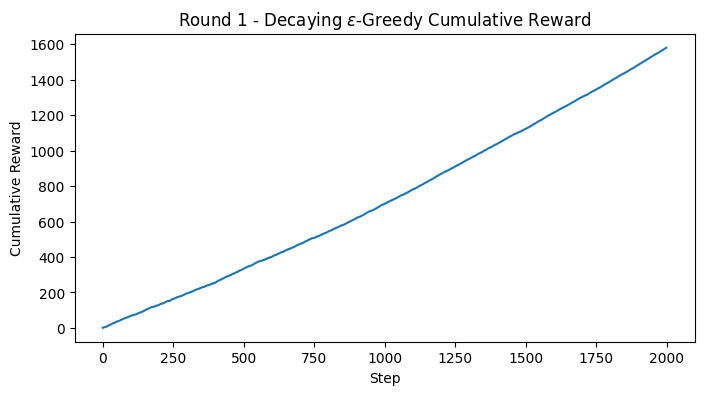

In [1]:

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8, 4)

def plot_cumulative(rewards, title="Cumulative Reward"):
    plt.figure()
    plt.plot(np.cumsum(rewards))
    plt.title(title)
    plt.xlabel("Step")
    plt.ylabel("Cumulative Reward")
    plt.show()

def epsilon_greedy_decaying(true_means, steps=1000, eps_start=0.5, eps_end=0.05, seed=None):
    rng = np.random.default_rng(seed)
    n_arms = len(true_means)
    Q = np.zeros(n_arms)
    N = np.zeros(n_arms)
    rewards = np.zeros(steps, dtype=float)
    actions = np.zeros(steps, dtype=int)
    for t in range(steps):
        epsilon = eps_end + (eps_start - eps_end) * max(0, (steps - 1 - t)) / max(1, steps - 1)
        if rng.random() < epsilon:
            a = rng.integers(0, n_arms)
        else:
            a = int(np.argmax(Q))
        r = 1.0 if rng.random() < true_means[a] else 0.0
        N[a] += 1
        Q[a] += (r - Q[a]) / N[a]
        rewards[t] = r
        actions[t] = a
    return rewards, actions, Q, N

# Stationary environment (seed=42 for fairness)
SEED_ENV = 42
rng_env = np.random.default_rng(SEED_ENV)
TRUE_MEANS = rng_env.random(10)
print("True means:", np.round(TRUE_MEANS, 3))

# Round 1: Decaying epsilon-greedy
rewards_r1, actions_r1, Q_r1, N_r1 = epsilon_greedy_decaying(
    TRUE_MEANS, steps=2000, eps_start=1.0, eps_end=0.01, seed=123
)
total_r1 = int(np.sum(rewards_r1))
print(f"Round 1 Total Reward (Decaying epsilon-greedy): {total_r1}")
print(f"Estimated Best Arm: {int(np.argmax(Q_r1))}")
plot_cumulative(rewards_r1, title=r"Round 1 - Decaying $\epsilon$-Greedy Cumulative Reward")


Round 2 Total Reward (Constant Alpha): 2599


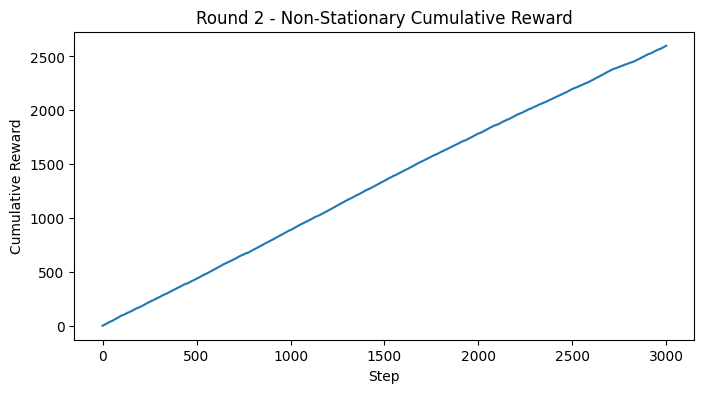

In [2]:

def step_drift(means, drift_scale=0.01, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    means = means + rng.normal(0, drift_scale, size=means.shape)
    return np.clip(means, 0.0, 1.0)

def epsilon_greedy_constant_alpha(steps=2000, n_arms=10, eps=0.1, alpha=0.1,
                                   seed_env=7, seed_agent=None, drift_scale=0.01):
    rng_env = np.random.default_rng(seed_env)
    rng_agent = np.random.default_rng(seed_agent)
    means = rng_env.random(n_arms)
    Q = np.zeros(n_arms)
    rewards = np.zeros(steps, dtype=float)
    actions = np.zeros(steps, dtype=int)
    for t in range(steps):
        if rng_agent.random() < eps:
            a = rng_agent.integers(0, n_arms)
        else:
            a = int(np.argmax(Q))
        r = 1.0 if rng_env.random() < means[a] else 0.0
        Q[a] = Q[a] + alpha * (r - Q[a])
        rewards[t] = r
        actions[t] = a
        means = step_drift(means, drift_scale=drift_scale, rng=rng_env)
    return rewards, actions, Q

# Round 2: Non-stationary with constant alpha
rewards_r2, actions_r2, Q_r2 = epsilon_greedy_constant_alpha(
    steps=3000, n_arms=10, eps=0.15, alpha=0.15,
    seed_env=2025, seed_agent=999, drift_scale=0.01
)
total_r2 = int(np.sum(rewards_r2))
print(f"Round 2 Total Reward (Constant Alpha): {total_r2}")
plot_cumulative(rewards_r2, title="Round 2 - Non-Stationary Cumulative Reward")


Thompson Sampling Total Reward: 1932


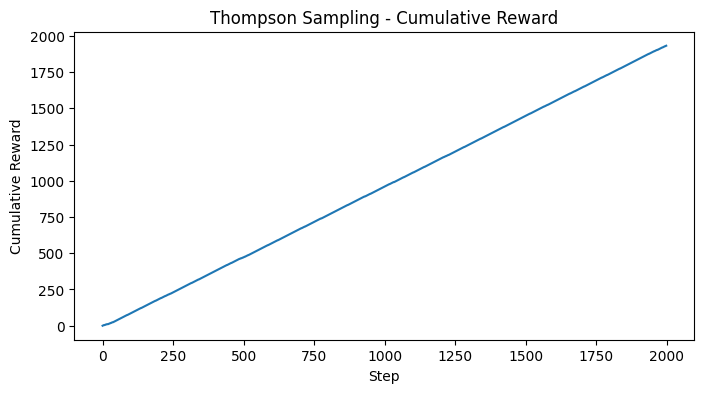

In [3]:

def thompson_sampling(true_means, steps=2000, seed=None):
    rng = np.random.default_rng(seed)
    n_arms = len(true_means)
    successes = np.zeros(n_arms)
    failures = np.zeros(n_arms)
    rewards = np.zeros(steps, dtype=float)
    actions = np.zeros(steps, dtype=int)
    for t in range(steps):
        samples = np.random.beta(successes + 1, failures + 1)
        a = int(np.argmax(samples))
        r = 1.0 if rng.random() < true_means[a] else 0.0
        if r > 0:
            successes[a] += 1
        else:
            failures[a] += 1
        rewards[t] = r
        actions[t] = a
    return rewards, actions, successes, failures

# Thompson Sampling on stationary environment
rewards_ts, actions_ts, succ_ts, fail_ts = thompson_sampling(
    TRUE_MEANS, steps=2000, seed=123
)
total_ts = int(np.sum(rewards_ts))
print(f"Thompson Sampling Total Reward: {total_ts}")
plot_cumulative(rewards_ts, title="Thompson Sampling - Cumulative Reward")



### Reflections & Discussions

**1. Strategy used and why:**
- **Round 1:** Decaying $\epsilon$-greedy (1.0 $\to$ 0.01). Heavy initial exploration guarantees finding the best arm; near-pure late exploitation maximizes reward.
- **Round 2:** Fixed $\epsilon$ (0.15) & Constant $\alpha$ (0.15). Constant $\alpha$ acts as an Exponential Moving Average (EMA) to prioritize recent rewards in a drifting environment.

**2. $\epsilon$ influence:**
- High $\epsilon$ wastes steps on suboptimal arms; Low $\epsilon$ risks premature convergence. Decaying $\epsilon$ dynamically optimizes this balance.

**3. Getting "stuck" & prevention:**
- Agents get stuck if $\epsilon$ decays to 0 too rapidly. Prevented by using a non-zero baseline $\epsilon$ or Optimistic Initial Values.

**4. Randomness vs Design:**
- **Design > Randomness.** Random seeds set the baseline luck, but intelligent algorithm design (decay schedules, Thompson Sampling) mathematically secures higher expected returns.

**5. Real-world Transfer:**
- **Stationary:** A/B Testing (fixed UI layout conversions).
- **Non-Stationary:** Recommender Systems (user preferences drift constantly).



## Talking Points
- **The Core Dilemma:** RL agents must continuously balance exploring unknown states to find better policies vs. exploiting known states to maximize immediate reward.
- **Stationarity:** When the environment dynamics are fixed, algorithms that decay exploration over time (like decaying $\epsilon$-greedy) mathematically converge to the optimal policy.
- **Non-Stationarity:** Real-world problems (like stock markets or user recommendations) drift. Using a constant step-size ($\alpha$) is crucial to override stale historical data with recent observations.
- **Thompson Sampling:** Beta-distribution sampling elegantly handles the exploration-exploitation trade-off by naturally exploring more when uncertainty is high and exploiting when confidence is strong.

## Conclusion
This exercise practically demonstrated how different RL algorithms adapt to environmental stability. While decaying $\epsilon$-greedy dominates in stationary settings by systematically eliminating suboptimal choices, it fails entirely in non-stationary environments. By introducing a constant step-size ($\alpha$) and maintaining a baseline exploration rate, the agent successfully learned to track drifting probabilities. Thompson Sampling provided a principled Bayesian alternative that probabilistically balances exploration and exploitation, proving that algorithmic flexibility is essential for dynamic real-world applications.
